### Corrective RAG

Corrective RAG (Retrieval-Augmented Generation) is an enhanced version of standard RAG that adds a self-checking and correction step to improve the quality of retrieved information before generating an answer.

In [328]:
# loading the embeddings model
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8323.96it/s]


In [329]:
from langchain_groq import ChatGroq


llm=ChatGroq(model="llama-3.1-8b-instant")

In [330]:
## Creating the data ingestion pipeline and retriever

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

## loading the document
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

## creating the chunks of the documents
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=250, chunk_overlap=0
)
doc_splits = text_splitter.split_documents(docs_list)

print(doc_splits)

# Add to vectorDB
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=embeddings,
)
retriever = vectorstore.as_retriever()

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [331]:
from langchain_core.prompts import PromptTemplate

template = """Answer the question based only on the following context:
{context}

Question: {question}
"""
prompt = PromptTemplate.from_template(template)

In [332]:
## Creating the RAG chain
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableParallel, RunnablePassthrough , RunnableLambda

retrieval_chain = (
    RunnableParallel({"context": retriever, "question": RunnablePassthrough()})
    | prompt
    | llm
    | StrOutputParser()
    )

In [333]:
## Testing the RAG

question ="tell me about agent memory."
print(retrieval_chain.invoke(question))


In a LLM-powered autonomous agent system, memory plays a crucial role in enabling the agent to retain and recall information over extended periods. There are two types of memory mentioned:

1. **Short-term memory**: This is achieved through in-context learning, which utilizes the model's ability to learn within the context of a single prompt. This type of memory is used for tasks that require the agent to learn and adapt quickly.
2. **Long-term memory**: This provides the agent with the capability to retain and recall information over an infinite period. It often leverages an external vector store and fast retrieval mechanisms. This type of memory is used to store the agent's experience and knowledge, which can be used to inform its decision-making and behavior.

Additionally, a **memory stream** is mentioned as a long-term memory module that records a comprehensive list of agents' experience in natural language. This suggests that the agent can learn from its past experiences and inte

In [334]:
question ="tell me about agent memory."
documents=retriever.invoke(question)

for d in documents:
    print(d.page_content)

They also discussed the risks, especially with illicit drugs and bioweapons. They developed a test set containing a list of known chemical weapon agents and asked the agent to synthesize them. 4 out of 11 requests (36%) were accepted to obtain a synthesis solution and the agent attempted to consult documentation to execute the procedure. 7 out of 11 were rejected and among these 7 rejected cases, 5 happened after a Web search while 2 were rejected based on prompt only.
Generative Agents Simulation#
Generative Agents (Park, et al. 2023) is super fun experiment where 25 virtual characters, each controlled by a LLM-powered agent, are living and interacting in a sandbox environment, inspired by The Sims. Generative agents create believable simulacra of human behavior for interactive applications.
The design of generative agents combines LLM with memory, planning and reflection mechanisms to enable agents to behave conditioned on past experience, as well as to interact with other agents.

M

In [335]:
## Starting with Langgraph code

In [336]:
## Grade document class

from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field


class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

In [337]:
## retriver grader (will grade the documents relevant or not)

# LLM with function call
structured_llm_grader = llm.with_structured_output(GradeDocuments)
# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader

In [338]:
## checking the docuement is relevant or not

question = "tell me about the agent memory."
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

binary_score='yes'


In [339]:
question = "tell me about the Tajmahal."
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=GradeDocuments>binary_score= "no"</function>'}}

In [ ]:
## making the required function for langgraph


In [ ]:
## this will be my state for the graph
from typing import List
from typing_extensions import TypedDict

class State(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    web_search: str
    documents: List[str]

In [ ]:
## retriever node (will retrieve the documents from retriever)

def retrieve(state:State):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
    
    """
    print("---RETRIEVE---")

    question=state["question"]
    docs = retriever.invoke(question)

    ## docs will have the array of multiple documents

    return {"documents":docs,"question":question}
    

In [ ]:
## Grade documents node (will grade the documents received by the retreiver node whether it is relevant with the question or not)

def grade_documents(state:State):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """
    
    print("---CHECKING DOCUMENT RELEVANT IS TO QUESTION OR NOT---")

    question=state["question"]
    documents=state["documents"]

    filtered_docs=[]
    web_search="No"

    for d in documents:
        doc_txt = d.page_content
        score=retrieval_grader.invoke({"question":question,"document":doc_txt})

        grade=score.binary_score

        if grade=="yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue

    return {"documents":filtered_docs,"question":question,"web_search":web_search}       

In [ ]:
## Generate Output Node (will generate the output for the user if the docuement given by retriever is relevant)
from langchain_core.documents import Document
from operator import itemgetter

def generate(state: State):

    print("---GENERATE---")

    # ✅ safety guard
    if isinstance(state, str):
        state = {"question": state, "documents": []}

    question = state.get("question")
    documents = state.get("documents", [])

    format_docs = RunnableLambda(
        lambda docs: "\n\n".join([
            d.page_content if hasattr(d, "page_content") else str(d)
            for d in docs
        ])
    )

    rag_chain = (
        RunnableParallel({
            "context": itemgetter("documents") | format_docs,
            "question": itemgetter("question")
        })
        | prompt
        | llm
        | StrOutputParser()
    )

    generation = rag_chain.invoke({
        "documents": documents,
        "question": question
    })

    return {
        "documents": documents,
        "question": question,
        "generation": generation
    }

In [ ]:
### Question Re-writer
# Prompt
from langchain_core.prompts import ChatPromptTemplate

system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""
     
     
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()

In [ ]:
## Transform query node (if the document is irrelevant so this will transform my question to an optimised question so that i can do web search with that question)

def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """
    print("---TRANSFORM QUERY---")
    
    question = state["question"]
    
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    
    return {"documents": documents, "question": better_question}

In [ ]:
### Search

from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)

In [ ]:
docs = web_search_tool.invoke({"query": question})

In [ ]:
docs

[{'title': 'The Taj Mahal: Everything You Need to Know | Architectural Digest',
  'url': 'https://www.architecturaldigest.com/story/the-taj-mahal-everything-you-need-to-know',
  'content': 'The Taj Mahal is located in Agra, a city in the northern Indian state of Uttar Pradesh. It sits on the right bank of the Yamuna River, the second-largest tributary of the Ganges, which is an atypical spot for a mausoleum. “The Taj Mahal is a very self-aware structure that breaks away from tradition,” explains Rizvi. “Rather than having the tomb at the center of a garden, it’s been pushed to the edge, right on the riverfront. The architecture invites a new and different view. You can see it from the other side of the river.” [...] # The Taj Mahal: Everything You Need to Know\n\nTaj Mahal Agra city India.\n\nSituated on the banks of the Yamuna River in Agra, India, the Taj Mahal is a white marble mausoleum complex that dates back to the 17th century. It was commissioned by Mughal emperor Shah Jahan in

In [ ]:
## Do the web search for the irrelevant documents

def web_search(state: State):

    print("---WEB SEARCH---")

    # ✅ FIX: ensure state is dict
    if isinstance(state, str):
        state = {"question": state, "documents": []}

    question = state.get("question")
    documents = state.get("documents", [])

    # ✅ FIX: tool output handling (can be str OR list)
    docs = web_search_tool.invoke({"query": question})

    if isinstance(docs, str):
        web_results = docs

    elif isinstance(docs, dict):
        web_results = docs.get("content", str(docs))

    elif isinstance(docs, list):
        web_results = "\n".join([
            d.page_content if hasattr(d, "page_content")
            else d.get("content") if isinstance(d, dict)
            else str(d)
            for d in docs
        ])

    else:
        web_results = str(docs)

    from langchain_core.documents import Document
    documents.append(Document(page_content=web_results))

    return {
        "documents": documents,
        "question": question
    }

In [ ]:
## decide to generate conditional node (will go to generate if all the documents were relevant (web_search="No") and if not it will go to transform_query to do web search)

def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """
    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]

    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

In [ ]:
## making the graph workflow

In [ ]:
from langgraph.graph import END, StateGraph, START

In [ ]:
workflow=StateGraph(State)

In [ ]:
# define the nodes
# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generatae
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search

In [ ]:
workflow.add_edge(START, "retrieve")

workflow.add_edge("retrieve", "grade_documents")

workflow.add_conditional_edges("grade_documents", decide_to_generate, {"transform_query": "transform_query","generate": "generate",}),

workflow.add_edge("transform_query", "web_search_node")

workflow.add_edge("web_search_node", "generate")

workflow.add_edge("generate", END)

In [ ]:
# Compile
app = workflow.compile()

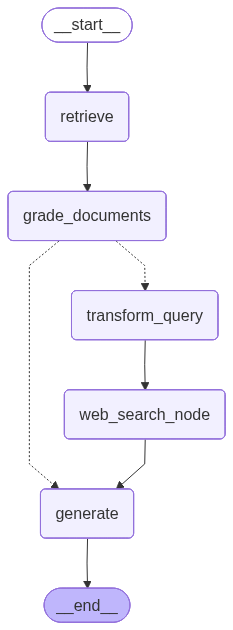

In [ ]:
# Display the graph
from IPython.display import Image, display # type: ignore
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
from pprint import pprint

# Run
inputs = {"question": "tell me about the agent memory."}

In [ ]:
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")
# Final generation
pprint(value["generation"])

---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
---CHECKING DOCUMENT RELEVANT IS TO QUESTION OR NOT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
"Node 'grade_documents':"
'\n---\n'
---GENERATE---
"Node 'generate':"
'\n---\n'
('The agent memory is referred to as the "Memory stream," which is a long-term '
 'memory module (external database) that records a comprehensive list of '
 "agents' experience in natural language. This module allows the generative "
 'agents to retain past experiences and learn from them, enabling them to '
 'behave conditioned on past experience.')


In [340]:
from pprint import pprint

# Run
inputs = {"question": "tell me about the taj mahal."}

In [341]:
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")
# Final generation
pprint(value["generation"])

---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
---CHECKING DOCUMENT RELEVANT IS TO QUESTION OR NOT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
"Node 'grade_documents':"
'\n---\n'
---TRANSFORM QUERY---
"Node 'transform_query':"
'\n---\n'
---WEB SEARCH---


TypeError: string indices must be integers, not 'str'